In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam

In [29]:
df = pd.read_csv("spotify_dataset.csv")
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [30]:
df_model = df.drop(columns=[
    'track_id', 'track_name', 'track_artist', 'track_album_id',
    'track_album_name', 'track_album_release_date', 'playlist_id',
    'playlist_genre', 'playlist_subgenre', 'playlist_name'
])

In [31]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

In [32]:
input_layer = Input(shape=(X_scaled.shape[1],))
x = Dense(64)(input_layer)
x = LeakyReLU()(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(32)(x)
x = LeakyReLU()(x)
x = BatchNormalization()(x)

encoded = Dense(4, activation='relu')(x)

x = Dense(32)(encoded)
x = LeakyReLU()(x)
x = BatchNormalization()(x)

x = Dense(64)(x)
x = LeakyReLU()(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

decoded = Dense(X_scaled.shape[1], activation='linear')(x)

autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)

autoencoder.compile(optimizer=Adam(learning_rate=5e-4), loss='mse')
history = autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, validation_split=0.1, verbose=0)

In [33]:
X_latent = encoder.predict(X_scaled)

1027/1027 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


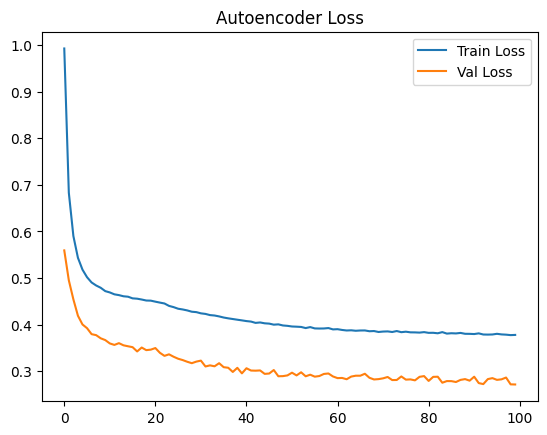

In [34]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Autoencoder Loss')
plt.legend()
plt.show()

In [35]:
kmeans = KMeans(n_clusters=10, random_state=42).fit(X_latent)
score = silhouette_score(X_latent, kmeans.labels_)
print("Silhouette Score (Latent Clustering):", round(score, 4))

Silhouette Score (Latent Clustering): 0.2177


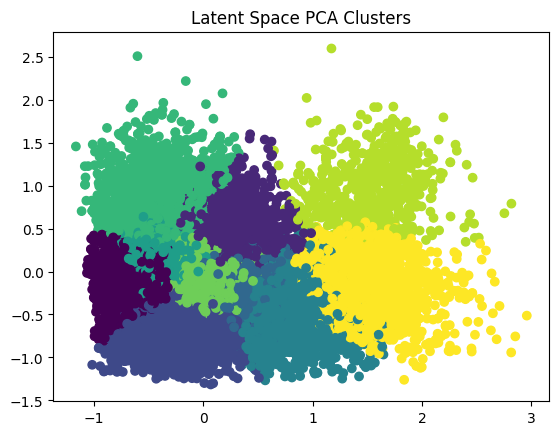

In [36]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_latent)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels_, cmap='viridis')
plt.title("Latent Space PCA Clusters")
plt.show()

In [37]:
latent_sim = cosine_similarity(X_latent)

In [38]:
genre_matrix = pd.get_dummies(df['playlist_genre'])
playlist_matrix = pd.get_dummies(df['playlist_name'])
meta_feat = pd.concat([genre_matrix, playlist_matrix], axis=1)
meta_sim = cosine_similarity(meta_feat)


In [ ]:
alpha = 0.7
hybrid_sim = alpha * latent_sim + (1 - alpha) * meta_sim

In [ ]:
popularity = df['track_popularity'].values / 100
hybrid_sim *= popularity[:, None]

In [ ]:
def hybrid_recommend(track_name, top_n=5):
    idx = df[df['track_name'].str.lower() == track_name.lower()].index
    if len(idx) == 0:
        return f"'{track_name}' not found"
    idx = idx[0]
    sim_scores = list(enumerate(hybrid_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    rec_indices = [i[0] for i in sim_scores[1:top_n+1]]
    return df[['track_name', 'track_artist', 'playlist_genre', 'playlist_name']].iloc[rec_indices]

                            track_name       track_artist playlist_genre
29622  Memories - Dillon Francis Remix           Maroon 5            edm
9713         Tres Delinquentes - Radio  Delinquent Habits            rap
20000        Tres Delinquentes - Radio  Delinquent Habits          latin
17947                  Robarte un Beso       Carlos Vives          latin
19217                  Robarte un Beso       Carlos Vives          latin


In [ ]:
print(hybrid_recommend("Memories - Dillon Francis Remix"))

Best silhouette score: 0.3594
Optimal number of clusters: 2
